# Heart Failure Mortality Risk Prediction

Goal: predict `DEATH_EVENT` from the Kaggle Heart Failure Clinical Data dataset.

Model: SMOTE tuned Stacking Ensemble with Logistic Regression, Random Forest, XGBoost, and SVM base learners, combined by a Random Forest meta-model.


## 1. Import Libraries


In [56]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
TARGET_COLUMN = "DEATH_EVENT"
TIME_COLUMN = "time"


## 2. Load Dataset


In [57]:
candidate_paths = [
    Path("heart_failure_prediction.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Dataset CSV not found in the current folder.")

df = pd.read_csv(data_path)
print(f"Loaded dataset: {data_path}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Loaded dataset: heart_failure_prediction.csv
Shape: 299 rows, 13 columns


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [58]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
df.isna().sum().sort_values(ascending=False)

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

## 3. Exploratory Data Analysis


In [60]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_summary = pd.DataFrame({
    "class": ["Survived", "Death Event"],
    "count": [target_counts.get(0, 0), target_counts.get(1, 0)],
    "percentage": [
        target_counts.get(0, 0) / len(df) * 100,
        target_counts.get(1, 0) / len(df) * 100,
    ],
})
target_summary


,class,count,percentage
0,Survived,203,67.892977
1,Death Event,96,32.107023


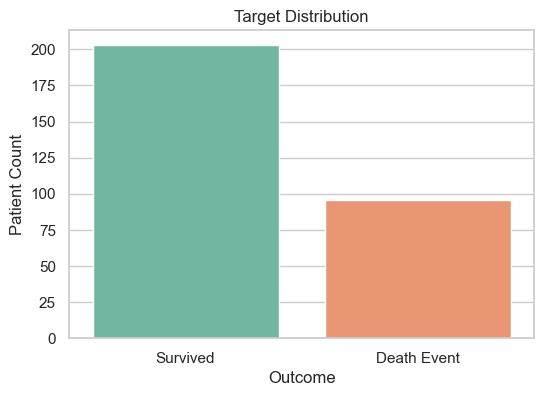

In [61]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COLUMN, hue=TARGET_COLUMN, palette="Set2", legend=False)
plt.xticks([0, 1], ["Survived", "Death Event"])
plt.title("Target Distribution")
plt.xlabel("Outcome")
plt.ylabel("Patient Count")
plt.show()


In [62]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


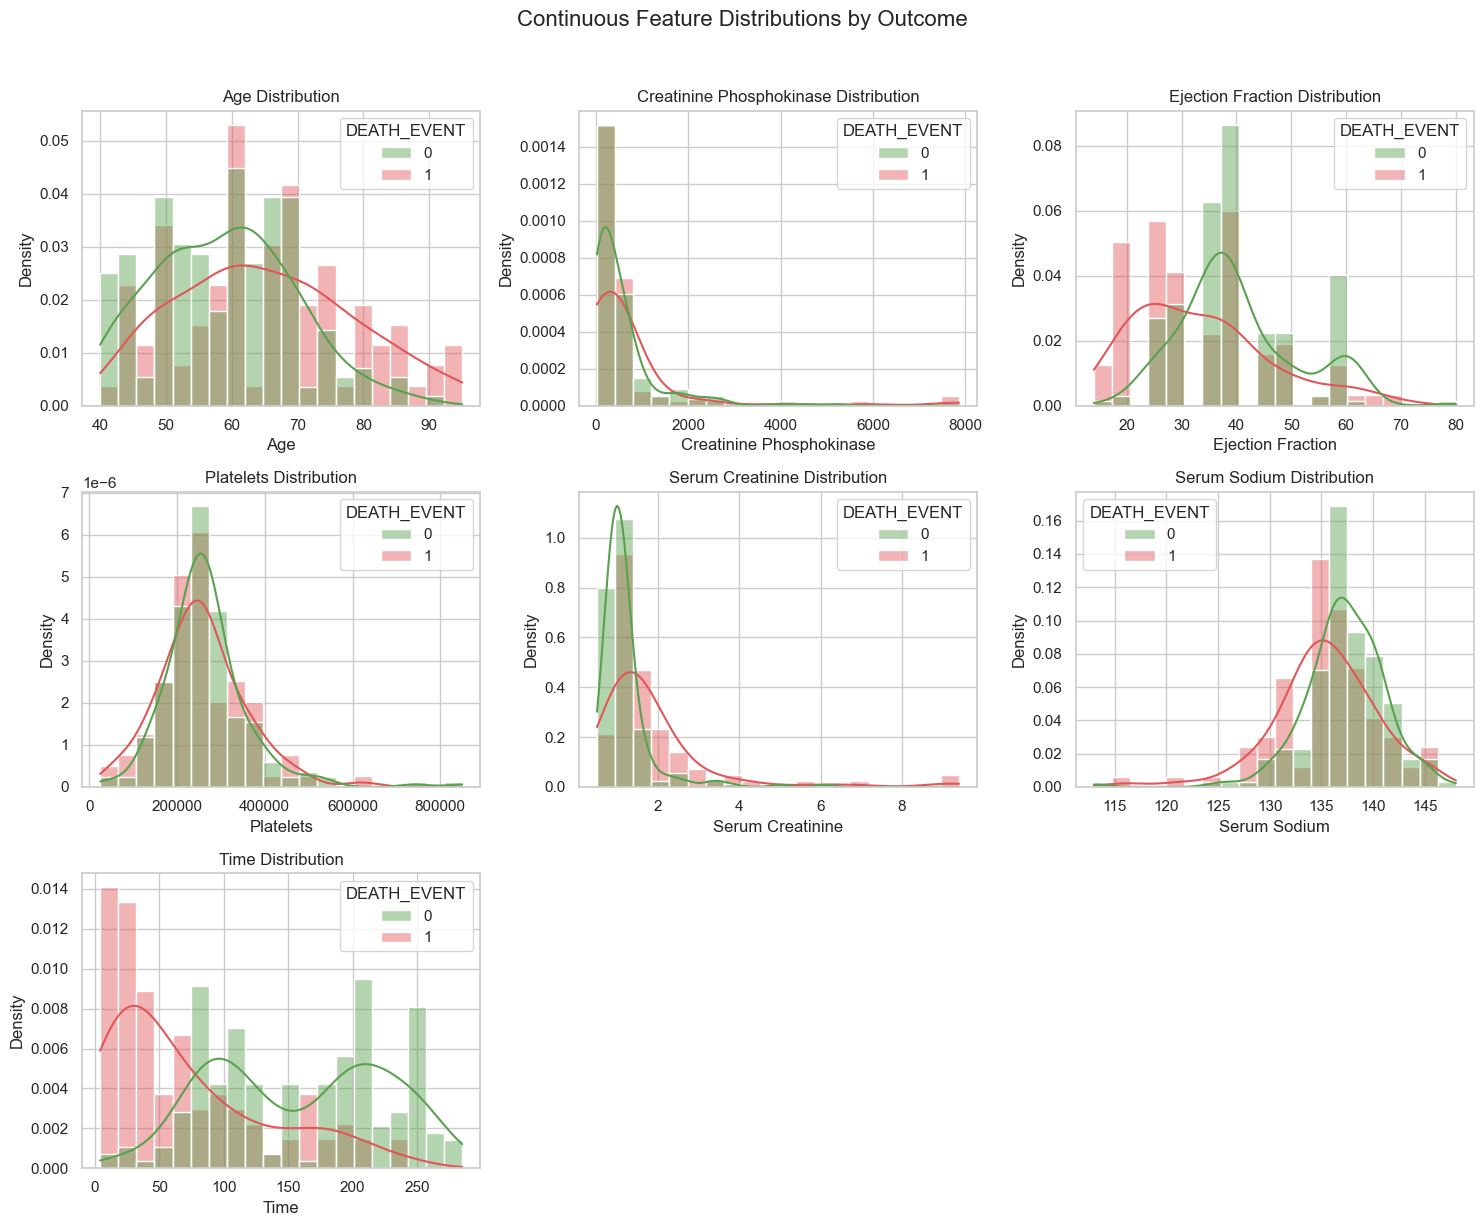

In [63]:
continuous_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
]
continuous_features = [feature for feature in continuous_features if feature in df.columns]

columns = 3
rows = int(np.ceil(len(continuous_features) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(15, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, continuous_features):
    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET_COLUMN,
        bins=20,
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.45,
        palette={0: "#59A14F", 1: "#E15759"},
        ax=ax,
    )
    ax.set_title(f"{feature.replace('_', ' ').title()} Distribution")
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel("Density")

for ax in axes[len(continuous_features):]:
    ax.set_visible(False)

fig.suptitle("Continuous Feature Distributions by Outcome", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


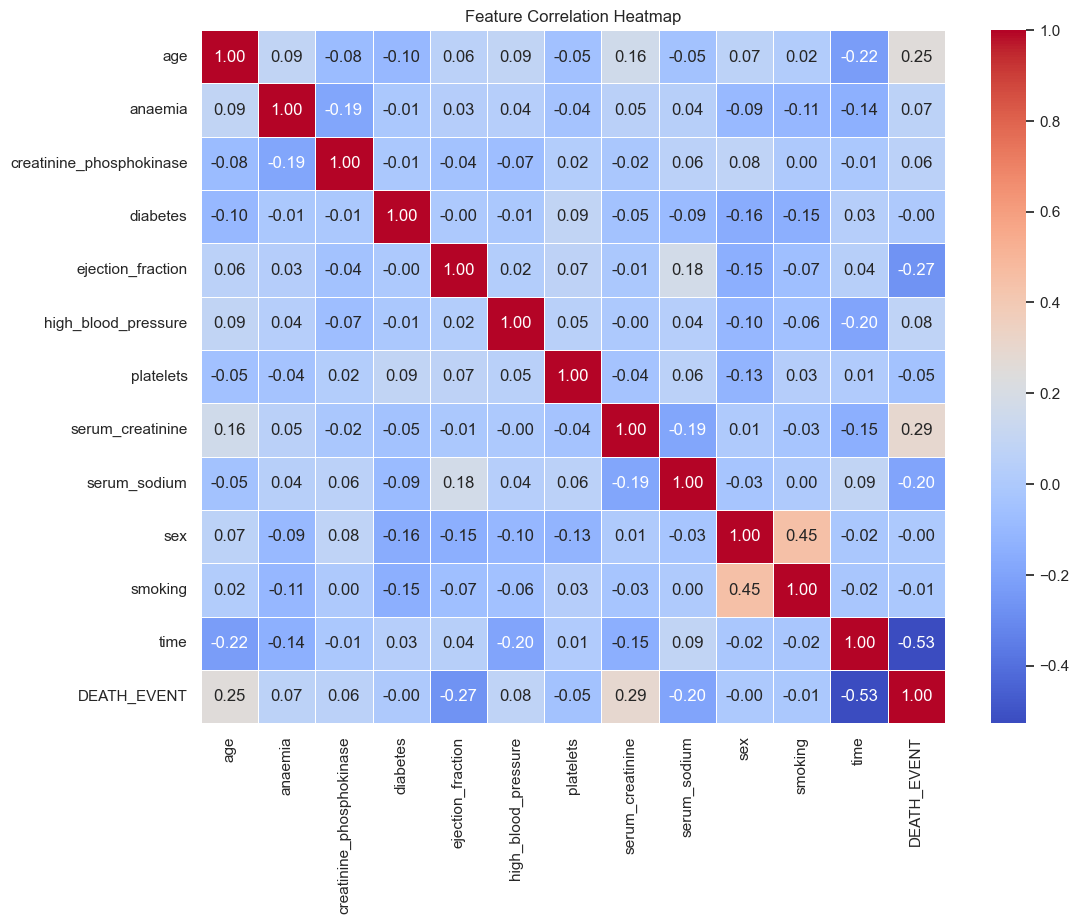

In [64]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


## 4. Feature and Target Preparation

The `time` column is excluded because it records follow-up duration and can leak outcome information into a baseline risk model.


In [65]:
INCLUDE_TIME = False

drop_columns = [TARGET_COLUMN]
if not INCLUDE_TIME:
    drop_columns.append(TIME_COLUMN)

X = df.drop(columns=drop_columns)
y = df[TARGET_COLUMN].astype(int)

print("Features used:")
print(list(X.columns))
print(f"\nTarget: {TARGET_COLUMN}")
print(f"Include time feature: {INCLUDE_TIME}")


Features used:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

Target: DEATH_EVENT
Include time feature: False


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")


Training rows: 209
Testing rows: 90


## 5. Build Base Learners for Stacking

Each base learner is wrapped in a pipeline so imputation, scaling where needed, and SMOTE stay inside the training folds.


In [67]:
def make_scaled_classifier(classifier):
    return ImbPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("classifier", classifier),
        ]
    )


def make_tree_classifier(classifier):
    return ImbPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("classifier", classifier),
        ]
    )


negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / max(positive_count, 1)

base_models = {
    "Logistic Regression": make_scaled_classifier(
        LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )
    ),
    "Random Forest": make_tree_classifier(
        RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
    "XGBoost": make_tree_classifier(
        XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
    "SVM": make_scaled_classifier(
        SVC(
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE,
        )
    ),
}

list(base_models.keys())


['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']

## 6. Tune Base Learners


Tuning Logistic Regression...
Tuning Random Forest...
Tuning XGBoost...
Tuning SVM...


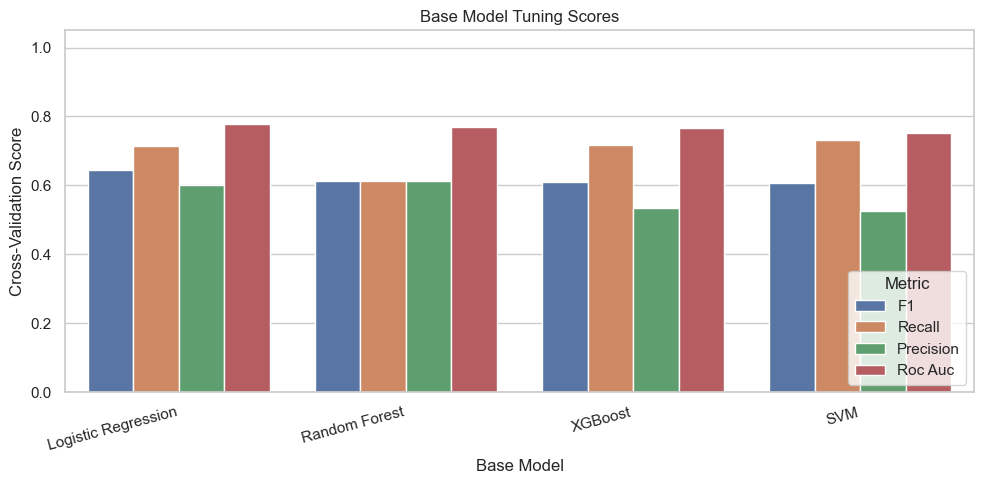

Logistic Regression: F1=0.644, Recall=0.714, Precision=0.601, ROC AUC=0.778
Random Forest: F1=0.612, Recall=0.612, Precision=0.614, ROC AUC=0.770
XGBoost: F1=0.611, Recall=0.716, Precision=0.534, ROC AUC=0.767
SVM: F1=0.608, Recall=0.731, Precision=0.524, ROC AUC=0.752


In [68]:
TUNING_ITERATIONS = 8
TUNING_CV_FOLDS = 3
TUNING_REFIT_METRIC = "f1"
TUNING_SCORING = {
    "f1": make_scorer(f1_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "roc_auc": "roc_auc",
}

tuning_cv = StratifiedKFold(
    n_splits=TUNING_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

search_spaces = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "classifier__penalty": ["l1", "l2"],
    },
    "Random Forest": {
        "classifier__n_estimators": [300, 500, 800],
        "classifier__max_depth": [None, 3, 5, 8],
        "classifier__min_samples_leaf": [1, 2, 4, 6],
        "classifier__max_features": ["sqrt", "log2", None],
    },
    "XGBoost": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [2, 3, 4],
        "classifier__learning_rate": [0.03, 0.05, 0.1],
        "classifier__subsample": [0.8, 0.9, 1.0],
        "classifier__colsample_bytree": [0.8, 0.9, 1.0],
        "classifier__reg_lambda": [1, 2, 5],
    },
    "SVM": {
        "classifier__C": [0.1, 0.3, 1, 3, 10],
        "classifier__gamma": ["scale", 0.01, 0.03, 0.1, 0.3],
    },
}

tuned_base_models = {}
tuning_rows = []

for model_name, model in base_models.items():
    print(f"Tuning {model_name}...")
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_spaces[model_name],
        n_iter=TUNING_ITERATIONS,
        scoring=TUNING_SCORING,
        cv=tuning_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=TUNING_REFIT_METRIC,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    tuned_base_models[model_name] = search.best_estimator_
    best_index = search.best_index_
    tuning_rows.append({
        "base_model": model_name,
        "best_cv_f1": search.best_score_,
        "best_cv_recall": search.cv_results_["mean_test_recall"][best_index],
        "best_cv_precision": search.cv_results_["mean_test_precision"][best_index],
        "best_cv_roc_auc": search.cv_results_["mean_test_roc_auc"][best_index],
        "best_parameters": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by=["best_cv_f1", "best_cv_recall", "best_cv_precision"], ascending=False
)

tuning_plot = tuning_results.melt(
    id_vars="base_model",
    value_vars=["best_cv_f1", "best_cv_recall", "best_cv_precision", "best_cv_roc_auc"],
    var_name="metric",
    value_name="score",
)
tuning_plot["metric"] = tuning_plot["metric"].str.replace("best_cv_", "", regex=False).str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tuning_plot, x="base_model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Base Model Tuning Scores")
ax.set_xlabel("Base Model")
ax.set_ylabel("Cross-Validation Score")
ax.legend(title="Metric", loc="lower right")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

for _, row in tuning_results.iterrows():
    print(
        f"{row['base_model']}: "
        f"F1={row['best_cv_f1']:.3f}, "
        f"Recall={row['best_cv_recall']:.3f}, "
        f"Precision={row['best_cv_precision']:.3f}, "
        f"ROC AUC={row['best_cv_roc_auc']:.3f}"
    )


## 7. Cross-Validate and Train Final Stacking Ensemble

The threshold is selected from out-of-fold training predictions, then the final model is fitted on the full training split.


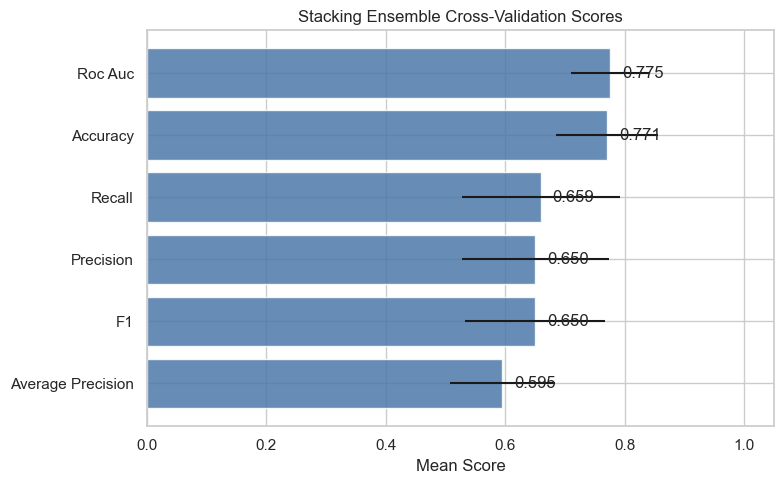

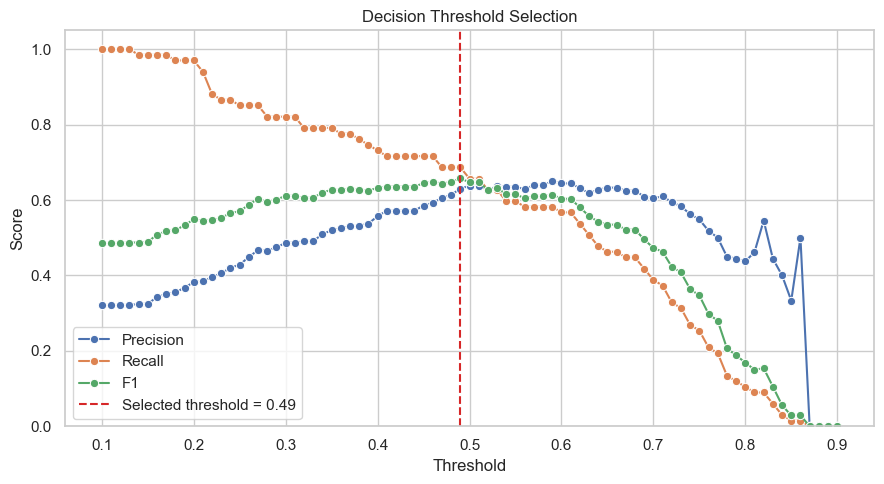

Optimized decision threshold: 0.49
Final model trained: SMOTE Tuned Stacking Ensemble with Random Forest meta-model


In [69]:
stacking_estimators = [
    ("lr", tuned_base_models["Logistic Regression"]),
    ("rf", tuned_base_models["Random Forest"]),
    ("xgb", tuned_base_models["XGBoost"]),
    ("svm", tuned_base_models["SVM"]),
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=RandomForestClassifier(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
    passthrough=True,
)

stack_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
stack_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

stack_cv_scores = cross_validate(
    stacking_model,
    X_train,
    y_train,
    scoring=stack_scoring,
    cv=stack_cv,
    n_jobs=-1,
    error_score="raise",
)

cv_results = pd.DataFrame([
    {
        "metric": metric_name,
        "mean": np.mean(stack_cv_scores[f"test_{metric_name}"]),
        "std": np.std(stack_cv_scores[f"test_{metric_name}"]),
    }
    for metric_name in stack_scoring
])
cv_results["label"] = cv_results["metric"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(8, 5))
cv_plot = cv_results.sort_values("mean")
ax.barh(cv_plot["label"], cv_plot["mean"], xerr=cv_plot["std"], color="#4C78A8", alpha=0.85)
ax.set_xlim(0, 1.05)
ax.set_title("Stacking Ensemble Cross-Validation Scores")
ax.set_xlabel("Mean Score")
ax.set_ylabel("")
for value, label in zip(cv_plot["mean"], cv_plot["label"]):
    ax.text(value + 0.02, label, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

out_of_fold_probability = cross_val_predict(
    stacking_model,
    X_train,
    y_train,
    cv=stack_cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.01):
    threshold_prediction = (out_of_fold_probability >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_train, threshold_prediction, zero_division=0),
        "recall": recall_score(y_train, threshold_prediction, zero_division=0),
        "f1": f1_score(y_train, threshold_prediction, zero_division=0),
    })

threshold_curve = pd.DataFrame(threshold_rows)
threshold_results = threshold_curve.sort_values(
    by=["f1", "recall", "precision"], ascending=False
).reset_index(drop=True)
OPTIMIZED_THRESHOLD = float(threshold_results.loc[0, "threshold"])

threshold_plot = threshold_curve.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)
threshold_plot["metric"] = threshold_plot["metric"].str.title()

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=threshold_plot, x="threshold", y="score", hue="metric", marker="o", ax=ax)
ax.axvline(OPTIMIZED_THRESHOLD, linestyle="--", color="#D62728", label=f"Selected threshold = {OPTIMIZED_THRESHOLD:.2f}")
ax.set_ylim(0, 1.05)
ax.set_title("Decision Threshold Selection")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Optimized decision threshold: {OPTIMIZED_THRESHOLD:.2f}")

stacking_model.fit(X_train, y_train)
print("Final model trained: SMOTE Tuned Stacking Ensemble with Random Forest meta-model")


## 8. Evaluate Final Model


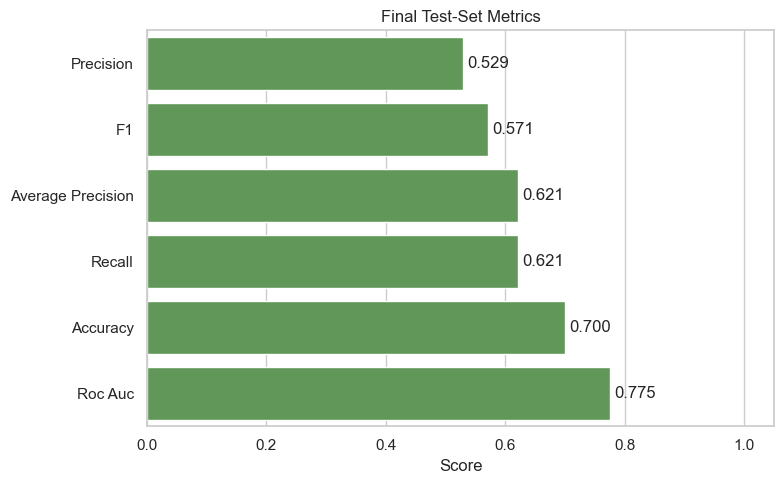

Confusion counts: TN=45, FP=16, FN=11, TP=18; threshold=0.49


In [70]:
THRESHOLD = OPTIMIZED_THRESHOLD

y_probability = stacking_model.predict_proba(X_test)[:, 1]
y_predicted = (y_probability >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_predicted).ravel()

metrics_df = pd.DataFrame([
    {
        "model": "SMOTE Tuned Stacking Ensemble",
        "accuracy": accuracy_score(y_test, y_predicted),
        "precision": precision_score(y_test, y_predicted, zero_division=0),
        "recall": recall_score(y_test, y_predicted, zero_division=0),
        "f1": f1_score(y_test, y_predicted, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_probability),
        "average_precision": average_precision_score(y_test, y_probability),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }
])

test_metric_plot = metrics_df[["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]].T.reset_index()
test_metric_plot.columns = ["metric", "score"]
test_metric_plot["label"] = test_metric_plot["metric"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=test_metric_plot.sort_values("score"), x="score", y="label", color="#59A14F", ax=ax)
ax.set_xlim(0, 1.05)
ax.set_title("Final Test-Set Metrics")
ax.set_xlabel("Score")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

print(
    f"Confusion counts: TN={tn}, FP={fp}, FN={fn}, TP={tp}; "
    f"threshold={THRESHOLD:.2f}"
)


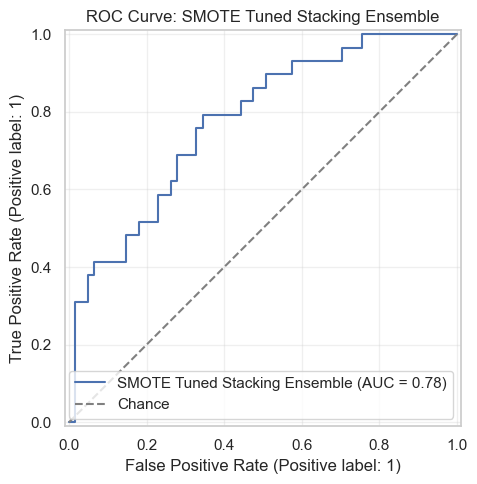

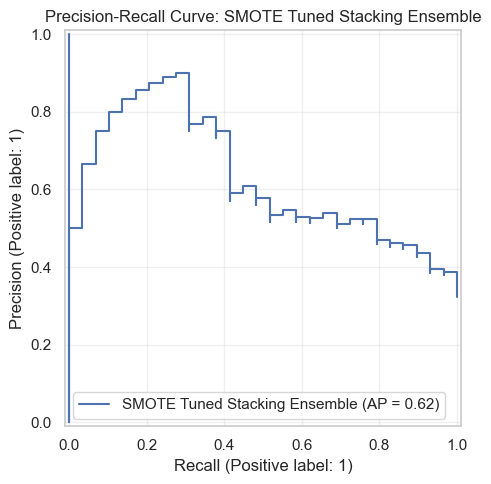

In [71]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name="SMOTE Tuned Stacking Ensemble",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve: SMOTE Tuned Stacking Ensemble")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probability,
    name="SMOTE Tuned Stacking Ensemble",
    ax=ax,
)
ax.set_title("Precision-Recall Curve: SMOTE Tuned Stacking Ensemble")
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


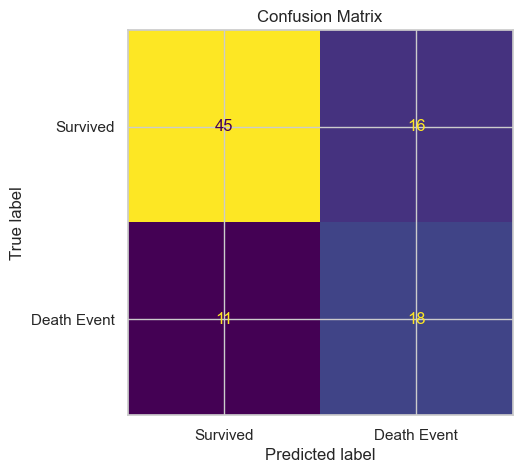

In [75]:
matrix = confusion_matrix(y_test, y_predicted)
fig, ax = plt.subplots(figsize=(6, 5))
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Survived", "Death Event"],
)
cm_display.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Confusion Matrix")
plt.show()


## 9. Final Notebook Report


Final notebook report
Project: Clinical Decision Support System for Heart Failure Mortality Risk Prediction
Dataset: heart_failure_prediction.csv
Rows: 299
Columns: 13
Target: DEATH_EVENT
Final Model: SMOTE Tuned Stacking Ensemble
Base Learners: Logistic Regression, Random Forest, XGBoost, SVM
Meta-Model: Random Forest
Features Used: age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking
Excluded Feature: time
Survived Cases: 203
Death Event Cases: 96
Decision Threshold: 0.49


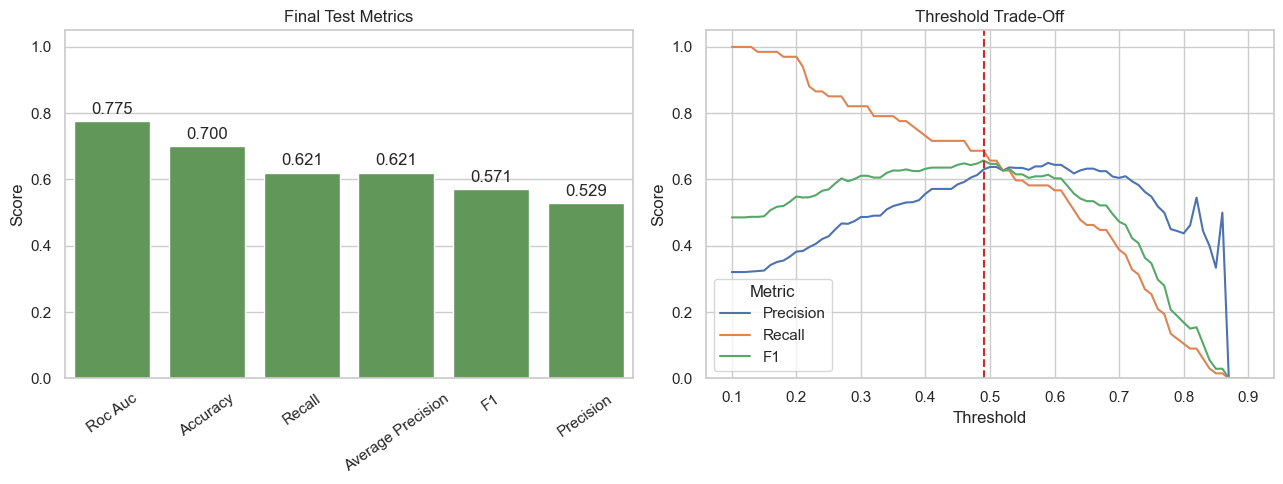

In [73]:
summary_lines = [
    ("Project", "Clinical Decision Support System for Heart Failure Mortality Risk Prediction"),
    ("Dataset", str(data_path)),
    ("Rows", f"{df.shape[0]}"),
    ("Columns", f"{df.shape[1]}"),
    ("Target", TARGET_COLUMN),
    ("Final Model", "SMOTE Tuned Stacking Ensemble"),
    ("Base Learners", "Logistic Regression, Random Forest, XGBoost, SVM"),
    ("Meta-Model", "Random Forest"),
    ("Features Used", ", ".join(X.columns)),
    ("Excluded Feature", TIME_COLUMN if not INCLUDE_TIME else "None"),
    ("Survived Cases", f"{int((y == 0).sum())}"),
    ("Death Event Cases", f"{int((y == 1).sum())}"),
    ("Decision Threshold", f"{THRESHOLD:.2f}"),
]

print("Final notebook report")
for label, value in summary_lines:
    print(f"{label}: {value}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=test_metric_plot.sort_values("score", ascending=False),
    x="label",
    y="score",
    color="#59A14F",
    ax=axes[0],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Final Test Metrics")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=35)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

sns.lineplot(data=threshold_plot, x="threshold", y="score", hue="metric", ax=axes[1])
axes[1].axvline(THRESHOLD, linestyle="--", color="#D62728")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Threshold Trade-Off")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].legend(title="Metric", loc="lower left")

plt.tight_layout()
plt.show()


## 10. Predict New Patient Risk


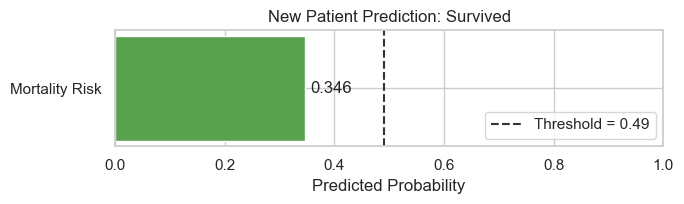

Mortality risk probability: 0.3459
Predicted DEATH_EVENT: 0


In [74]:
new_patient = {
    "age": 65,
    "anaemia": 0,
    "creatinine_phosphokinase": 250,
    "diabetes": 1,
    "ejection_fraction": 35,
    "high_blood_pressure": 1,
    "platelets": 263000,
    "serum_creatinine": 1.3,
    "serum_sodium": 136,
    "sex": 1,
    "smoking": 0,
}

new_patient_df = pd.DataFrame([new_patient])
risk_probability = stacking_model.predict_proba(new_patient_df[X.columns])[:, 1]
prediction = (risk_probability >= THRESHOLD).astype(int)

risk_score = float(risk_probability[0])
risk_label = "Death Event" if int(prediction[0]) == 1 else "Survived"

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.barh(["Mortality Risk"], [risk_score], color="#E15759" if prediction[0] else "#59A14F")
ax.axvline(THRESHOLD, linestyle="--", color="#333333", label=f"Threshold = {THRESHOLD:.2f}")
ax.set_xlim(0, 1)
ax.set_title(f"New Patient Prediction: {risk_label}")
ax.set_xlabel("Predicted Probability")
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{risk_score:.3f}"], padding=4)
plt.tight_layout()
plt.show()

print(f"Mortality risk probability: {risk_score:.4f}")
print(f"Predicted DEATH_EVENT: {int(prediction[0])}")


## 11. Conclusion

The tuned stacking ensemble gives the final test-set prediction result shown above. Before clinical use, the model still needs external validation, calibration review, and approval by qualified clinical stakeholders.
